# Recommender Systems (Matrix Factorization) 🍿
This notebook demonstrates a simple recommender system using Matrix Factorization via Gradient Descent.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
R = np.array([
    [5, 3, 0, 1],
    [4, 0, 0, 1],
    [1, 1, 0, 5],
    [1, 0, 0, 4],
    [0, 1, 5, 4],
])

num_users, num_items = R.shape
K = 2
P = np.random.rand(num_users, K)
Q = np.random.rand(num_items, K)

alpha = 0.01
beta = 0.02
iterations = 1000
loss_history = []

for step in range(iterations):
    for i in range(num_users):
        for j in range(num_items):
            if R[i][j] > 0:
                eij = R[i][j] - np.dot(P[i,:], Q[j,:].T)
                for k in range(K):
                    # Use the pre-update P[i][k] for both updates so
                    # they are simultaneous gradient steps derived from
                    # the same error eij, not a stale-error/fresh-param mix.
                    p_ik = P[i][k]
                    P[i][k] = p_ik + alpha * (2 * eij * Q[j][k] - beta * p_ik)
                    Q[j][k] = Q[j][k] + alpha * (2 * eij * p_ik - beta * Q[j][k])
    
    e = 0
    for i in range(num_users):
        for j in range(num_items):
            if R[i][j] > 0:
                e += pow(R[i][j] - np.dot(P[i,:], Q[j,:].T), 2)
                for k in range(K):
                    e += (beta/2) * (pow(P[i][k], 2) + pow(Q[j][k], 2))
    loss_history.append(e)
    if e < 0.001:
        break

pred_R = np.dot(P, Q.T)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='purple')
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Error')

plt.subplot(1, 2, 2)
plt.imshow(pred_R, cmap='viridis')
plt.colorbar()
plt.title('Predicted Ratings Matrix')
plt.show()


## 🤝 Collaborative Filtering (User-User)
Recommends items by finding similar users using cosine similarity.

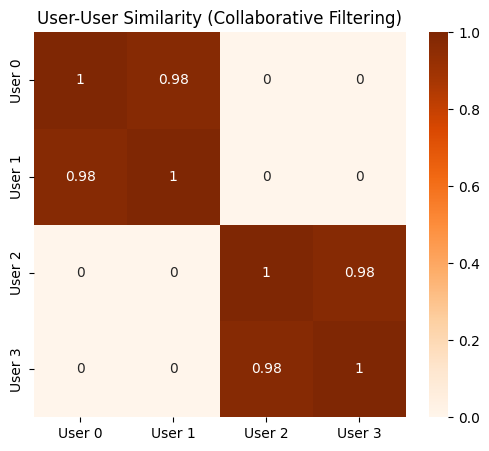

In [2]:

from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# Dummy user-item ratings matrix (4 users, 4 items)
ratings = np.array([
    [5, 4, 0, 0],
    [4, 5, 0, 0],
    [0, 0, 5, 4],
    [0, 0, 4, 5]
])

user_sim = cosine_similarity(ratings)
plt.figure(figsize=(6, 5))
sns.heatmap(user_sim, annot=True, cmap='Oranges', xticklabels=[f'User {i}' for i in range(4)], yticklabels=[f'User {i}' for i in range(4)])
plt.title("User-User Similarity (Collaborative Filtering)")
plt.show()


## 📚 Content-Based Filtering
Recommends items similar to those a given user has liked, based on item features.

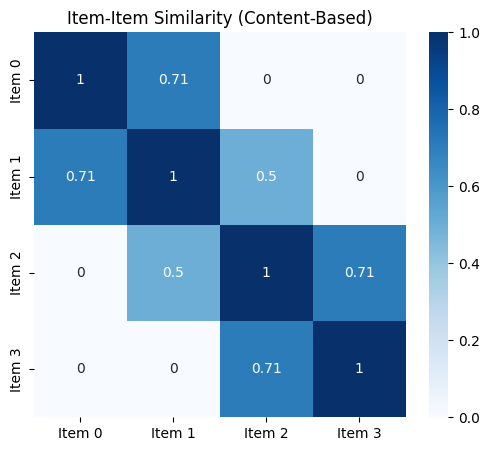

In [3]:

# Dummy item features (e.g., genres: Action, Sci-Fi, Fantasy)
item_features = np.array([
    [1, 0, 0], # Item 0: Action
    [1, 1, 0], # Item 1: Action, Sci-Fi
    [0, 1, 1], # Item 2: Sci-Fi, Fantasy
    [0, 0, 1]  # Item 3: Fantasy
])

item_sim = cosine_similarity(item_features)
plt.figure(figsize=(6, 5))
sns.heatmap(item_sim, annot=True, cmap='Blues', xticklabels=[f'Item {i}' for i in range(4)], yticklabels=[f'Item {i}' for i in range(4)])
plt.title("Item-Item Similarity (Content-Based)")
plt.show()


## 🧠 Neural Collaborative Filtering (NCF)
Uses neural networks and embeddings to learn complex, non-linear user-item interactions.

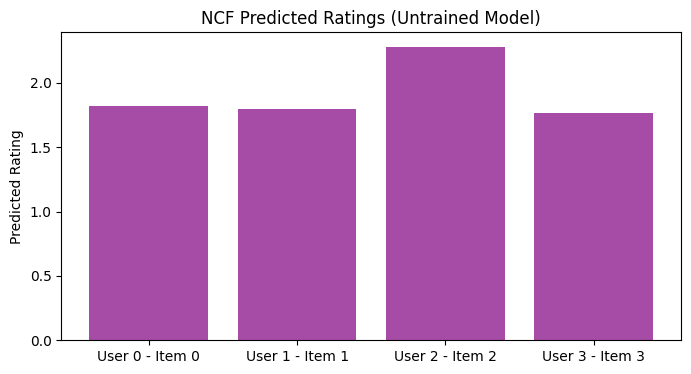

In [4]:

import torch
import torch.nn as nn

class NCF(nn.Module):
    def __init__(self, num_users, num_items, embed_size=8):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embed_size)
        self.item_embedding = nn.Embedding(num_items, embed_size)
        self.fc1 = nn.Linear(embed_size * 2, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, user, item):
        u_emb = self.user_embedding(user)
        i_emb = self.item_embedding(item)
        x = torch.cat([u_emb, i_emb], dim=-1)
        x = self.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x)) * 5 # Scale to 0-5 rating

# Initialize model and simulate a forward pass
ncf_model = NCF(4, 4)
user_idx = torch.tensor([0, 1, 2, 3])
item_idx = torch.tensor([0, 1, 2, 3])
with torch.no_grad():
    preds = ncf_model(user_idx, item_idx)

plt.figure(figsize=(8, 4))
plt.bar(range(4), preds.numpy().flatten(), color='purple', alpha=0.7)
plt.xticks(range(4), [f'User {i} - Item {i}' for i in range(4)])
plt.ylabel('Predicted Rating')
plt.title('NCF Predicted Ratings (Untrained Model)')
plt.show()
